# Cross-Language Diarization Performance Comparison

This notebook compares streaming diarization system performance across **CallHome English** and **CallHome German** datasets.

**Metrics Compared:**
- **DER** (Diarization Error Rate) - Overall error including FA, Miss, and Confusion
- **Detection Error** - False Alarm + Missed Detection (speaker-agnostic)
- **JER** (Jaccard Error Rate) - Frame-level overlap error metric

**Systems:**
- `diart_default` - DIART with default parameters
- `diart_custom` - DIART with custom parameters
- `streaming_sortformer` - Streaming SortFormer system

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Import analysis modules
import data_loader
import stats_report

# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

## Load Data from Both Languages

In [2]:
# Load CallHome English results
eng_path = Path("../results/callhome_eng/metrics.csv")
df_eng = data_loader.load_metrics(eng_path, verbose=False)
df_eng['language'] = 'English'

# Load CallHome German results
deu_path = Path("../results/callhome_deu/metrics.csv")
df_deu = data_loader.load_metrics(deu_path, verbose=False)
df_deu['language'] = 'German'

# Combine datasets
df_combined = pd.concat([df_eng, df_deu], ignore_index=True)

print(f"English recordings: {df_eng['recording_id'].nunique()}")
print(f"German recordings: {df_deu['recording_id'].nunique()}")
print(f"Systems: {df_combined['system'].unique().tolist()}")
print(f"\nTotal rows: {len(df_combined)}")

English recordings: 140
German recordings: 120
Systems: ['diart_default', 'diart_custom', 'streaming_sortformer']

Total rows: 780


## Calculate Detection Error Rate

Detection Error = False Alarm + Missed Detection (excludes speaker confusion)

In [3]:
# Add Detection Error Rate column
df_combined['detection_error'] = (df_combined['false_alarm'] + 
                                   df_combined['missed_detection']) / df_combined['total_speech_time']

# Verify calculation
print("Sample Detection Error values:")
print(df_combined[['system', 'language', 'DER', 'detection_error', 'JER']].head(10))

Sample Detection Error values:
          system language     DER  detection_error     JER
0  diart_default  English  0.1707           0.1226  0.2458
1  diart_default  English  0.3934           0.1913  0.4852
2  diart_default  English  0.4511           0.1481  0.6323
3  diart_default  English  0.4839           0.2502  0.5901
4  diart_default  English  0.4796           0.1173  0.6330
5  diart_default  English  0.2896           0.1505  0.4963
6  diart_default  English  0.4909           0.2644  0.6715
7  diart_default  English  0.3445           0.2454  0.4611
8  diart_default  English  0.3188           0.1347  0.5678
9  diart_default  English  0.4907           0.1335  0.6564


## Summary Statistics by Language and System

In [4]:
# Calculate mean metrics by language and system
summary = df_combined.groupby(['language', 'system']).agg({
    'DER': 'mean',
    'detection_error': 'mean',
    'JER': 'mean',
    'recording_id': 'count'
}).rename(columns={'recording_id': 'num_recordings'})

print("Mean Performance by Language and System:")
print("="*80)
display(summary.round(4))

Mean Performance by Language and System:


DER  detection_error     JER  num_recordings
language system                                                               
English  diart_custom          0.4162           0.1700  0.4857             140
         diart_default         0.4221           0.1664  0.5276             140
         streaming_sortformer  0.2024           0.1757  0.2144             140
German   diart_custom          0.4005           0.1746  0.4908             120
         diart_default         0.4329           0.1827  0.5257             120
         streaming_sortformer  0.1913           0.1524  0.2070             120

## Visualization: DER Comparison Across Languages

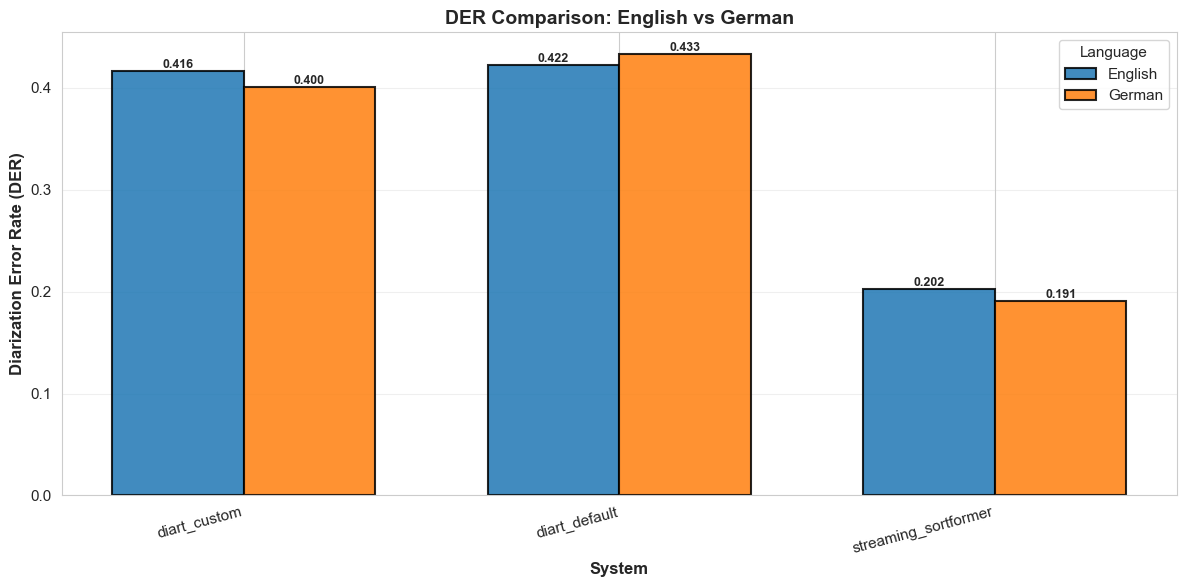

In [5]:
# Prepare data for plotting
metrics_summary = df_combined.groupby(['language', 'system']).agg({
    'DER': 'mean',
    'detection_error': 'mean',
    'JER': 'mean'
}).reset_index()

# Create grouped bar chart for DER
fig, ax = plt.subplots(figsize=(12, 6))

languages = metrics_summary['language'].unique()
systems = metrics_summary['system'].unique()
x = np.arange(len(systems))
width = 0.35

for i, lang in enumerate(languages):
    lang_data = metrics_summary[metrics_summary['language'] == lang]
    offset = width * (i - 0.5)
    bars = ax.bar(x + offset, lang_data['DER'], width, 
                  label=lang, alpha=0.85, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('System', fontsize=12, fontweight='bold')
ax.set_ylabel('Diarization Error Rate (DER)', fontsize=12, fontweight='bold')
ax.set_title('DER Comparison: English vs German', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(systems, rotation=15, ha='right')
ax.legend(title='Language', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Visualization: Detection Error Rate Comparison

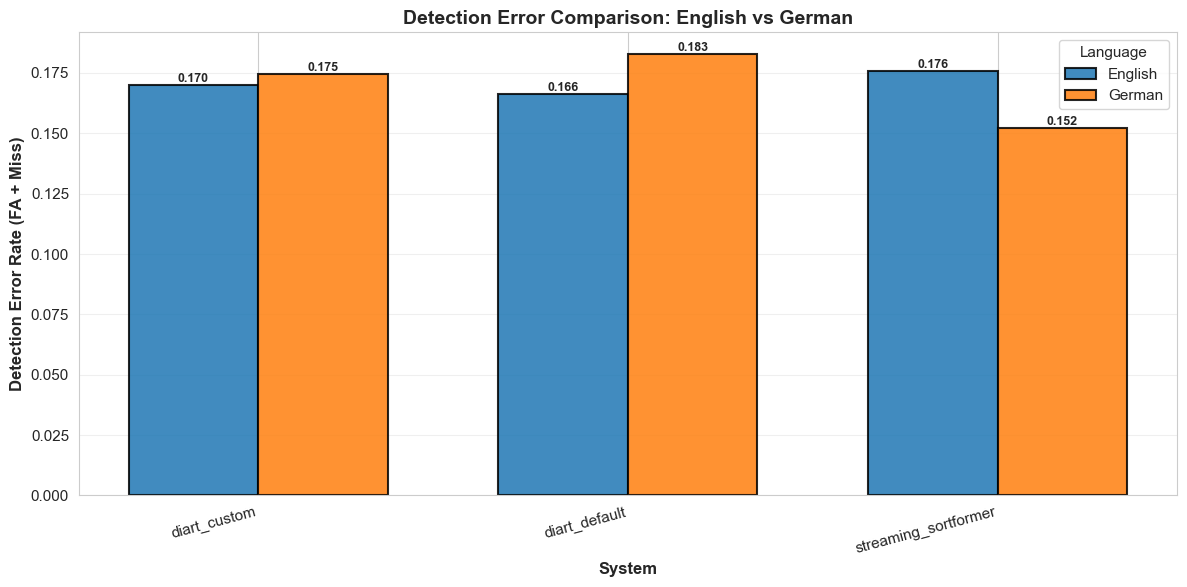

In [6]:
# Create grouped bar chart for Detection Error
fig, ax = plt.subplots(figsize=(12, 6))

for i, lang in enumerate(languages):
    lang_data = metrics_summary[metrics_summary['language'] == lang]
    offset = width * (i - 0.5)
    bars = ax.bar(x + offset, lang_data['detection_error'], width, 
                  label=lang, alpha=0.85, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('System', fontsize=12, fontweight='bold')
ax.set_ylabel('Detection Error Rate (FA + Miss)', fontsize=12, fontweight='bold')
ax.set_title('Detection Error Comparison: English vs German', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(systems, rotation=15, ha='right')
ax.legend(title='Language', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Visualization: JER Comparison

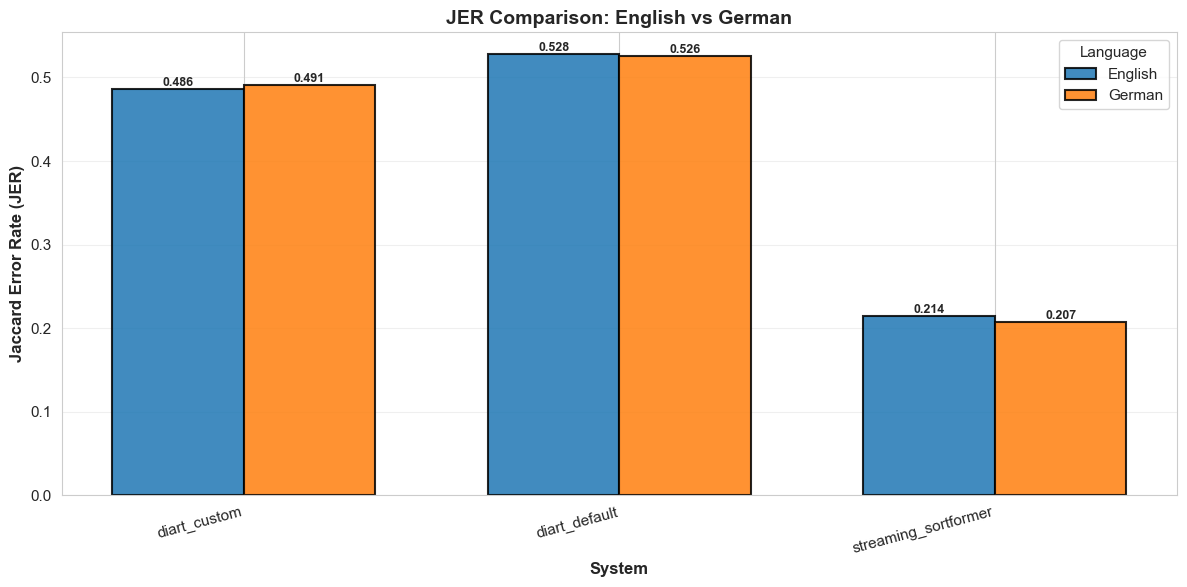

In [7]:
# Create grouped bar chart for JER
fig, ax = plt.subplots(figsize=(12, 6))

for i, lang in enumerate(languages):
    lang_data = metrics_summary[metrics_summary['language'] == lang]
    offset = width * (i - 0.5)
    bars = ax.bar(x + offset, lang_data['JER'], width, 
                  label=lang, alpha=0.85, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('System', fontsize=12, fontweight='bold')
ax.set_ylabel('Jaccard Error Rate (JER)', fontsize=12, fontweight='bold')
ax.set_title('JER Comparison: English vs German', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(systems, rotation=15, ha='right')
ax.legend(title='Language', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## All Metrics Side-by-Side Comparison

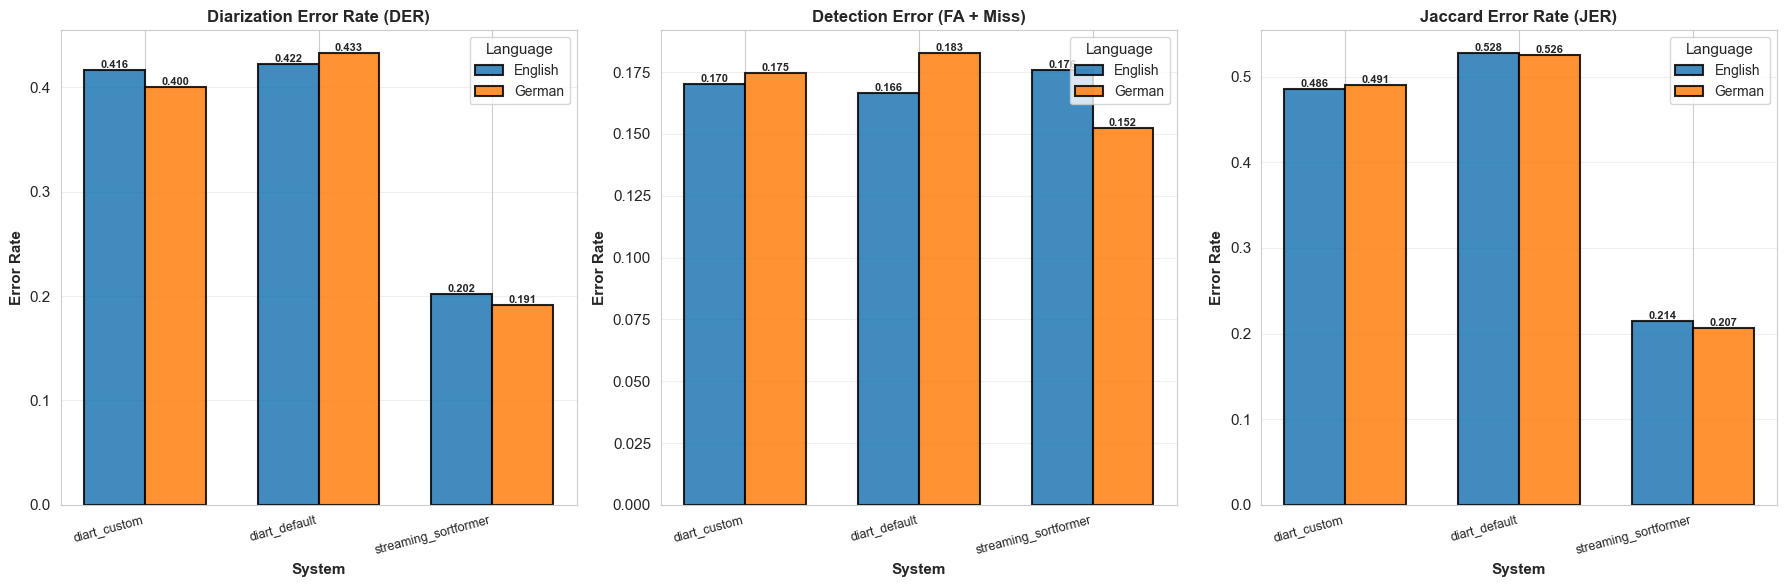

In [8]:
# Create comprehensive comparison with all three metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metric_info = [
    ('DER', 'Diarization Error Rate (DER)', axes[0]),
    ('detection_error', 'Detection Error (FA + Miss)', axes[1]),
    ('JER', 'Jaccard Error Rate (JER)', axes[2])
]

for metric_name, title, ax in metric_info:
    for i, lang in enumerate(languages):
        lang_data = metrics_summary[metrics_summary['language'] == lang]
        offset = width * (i - 0.5)
        bars = ax.bar(x + offset, lang_data[metric_name], width, 
                      label=lang, alpha=0.85, edgecolor='black', linewidth=1.5)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    ax.set_xlabel('System', fontsize=11, fontweight='bold')
    ax.set_ylabel('Error Rate', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(systems, rotation=15, ha='right', fontsize=9)
    ax.legend(title='Language', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## System Ranking by Language

In [9]:
# Rank systems for each language based on DER
print("System Rankings by Language (DER - lower is better)")
print("="*80)

for lang in languages:
    lang_data = metrics_summary[metrics_summary['language'] == lang].sort_values('DER')
    print(f"\n{lang}:")
    for idx, (_, row) in enumerate(lang_data.iterrows(), 1):
        print(f"  {idx}. {row['system']:25s} - DER: {row['DER']:.4f}, "
              f"Det: {row['detection_error']:.4f}, JER: {row['JER']:.4f}")

System Rankings by Language (DER - lower is better)

English:
  1. streaming_sortformer      - DER: 0.2024, Det: 0.1757, JER: 0.2144
  2. diart_custom              - DER: 0.4162, Det: 0.1700, JER: 0.4857
  3. diart_default             - DER: 0.4221, Det: 0.1664, JER: 0.5276

German:
  1. streaming_sortformer      - DER: 0.1913, Det: 0.1524, JER: 0.2070
  2. diart_custom              - DER: 0.4005, Det: 0.1746, JER: 0.4908
  3. diart_default             - DER: 0.4329, Det: 0.1827, JER: 0.5257


## Language Difficulty Analysis

Which language is more challenging for diarization?

Language Difficulty Comparison (averaged across all systems):


,DER,detection_error,JER,gt_overlap_rate,gt_num_speakers
language,,,,,
English,0.3469,0.1707,0.4092,0.0790,2.1000
German,0.3416,0.1699,0.4078,0.1114,2.1667


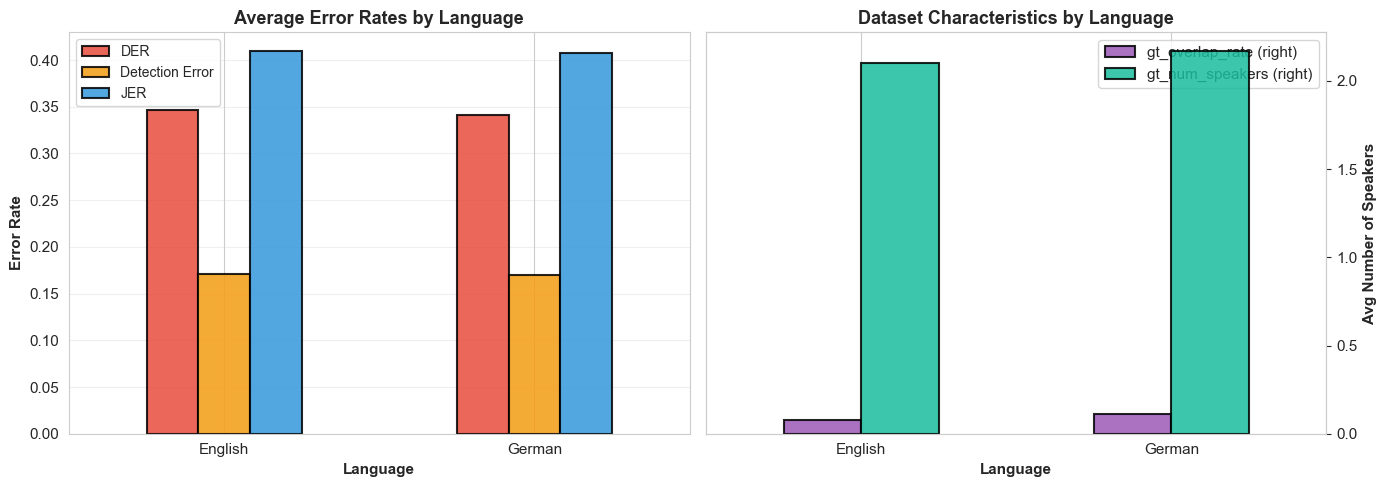

In [10]:
# Compare average performance across all systems
lang_difficulty = df_combined.groupby('language').agg({
    'DER': 'mean',
    'detection_error': 'mean',
    'JER': 'mean',
    'gt_overlap_rate': 'mean',
    'gt_num_speakers': 'mean'
}).round(4)

print("Language Difficulty Comparison (averaged across all systems):")
print("="*80)
display(lang_difficulty)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error rates
metrics_to_plot = ['DER', 'detection_error', 'JER']
lang_difficulty[metrics_to_plot].plot(kind='bar', ax=axes[0], 
                                      color=['#e74c3c', '#f39c12', '#3498db'],
                                      alpha=0.85, edgecolor='black', linewidth=1.5)
axes[0].set_title('Average Error Rates by Language', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Language', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Error Rate', fontsize=11, fontweight='bold')
axes[0].legend(['DER', 'Detection Error', 'JER'], fontsize=10)
axes[0].set_xticklabels(lang_difficulty.index, rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Dataset characteristics
lang_difficulty[['gt_overlap_rate', 'gt_num_speakers']].plot(kind='bar', ax=axes[1],
                                                               color=['#9b59b6', '#1abc9c'],
                                                               alpha=0.85, edgecolor='black', 
                                                               linewidth=1.5, secondary_y=True)
axes[1].set_title('Dataset Characteristics by Language', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Language', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Overlap Rate', fontsize=11, fontweight='bold')
axes[1].right_ax.set_ylabel('Avg Number of Speakers', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(lang_difficulty.index, rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Statistical Comparison

Test if performance differences between languages are significant.

In [11]:
from scipy import stats

print("Statistical Significance Tests (Welch's t-test)")
print("="*80)

for system in systems:
    print(f"\n{system}:")
    
    eng_data = df_combined[(df_combined['system'] == system) & 
                           (df_combined['language'] == 'English')]
    deu_data = df_combined[(df_combined['system'] == system) & 
                           (df_combined['language'] == 'German')]
    
    for metric in ['DER', 'detection_error', 'JER']:
        t_stat, p_value = stats.ttest_ind(eng_data[metric], deu_data[metric], 
                                          equal_var=False)
        
        eng_mean = eng_data[metric].mean()
        deu_mean = deu_data[metric].mean()
        diff = deu_mean - eng_mean
        
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        
        print(f"  {metric:20s}: Eng={eng_mean:.4f}, Deu={deu_mean:.4f}, "
              f"Diff={diff:+.4f}, p={p_value:.4f} {significance}")

print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

Statistical Significance Tests (Welch's t-test)

diart_custom:
  DER                 : Eng=0.4162, Deu=0.4005, Diff=-0.0157, p=0.2387 ns
  detection_error     : Eng=0.1700, Deu=0.1746, Diff=+0.0046, p=0.4363 ns
  JER                 : Eng=0.4857, Deu=0.4908, Diff=+0.0051, p=0.7586 ns

diart_default:
  DER                 : Eng=0.4221, Deu=0.4329, Diff=+0.0108, p=0.4179 ns
  detection_error     : Eng=0.1664, Deu=0.1827, Diff=+0.0163, p=0.0059 **
  JER                 : Eng=0.5276, Deu=0.5257, Diff=-0.0019, p=0.9027 ns

streaming_sortformer:
  DER                 : Eng=0.2024, Deu=0.1913, Diff=-0.0112, p=0.2068 ns
  detection_error     : Eng=0.1757, Deu=0.1524, Diff=-0.0233, p=0.0001 ***
  JER                 : Eng=0.2144, Deu=0.2070, Diff=-0.0075, p=0.4859 ns

Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


## Distribution Comparison with Box Plots

C:\Users\mbielak\AppData\Local\Temp\ipykernel_89756\1110888409.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, positions=positions, labels=labels,
C:\Users\mbielak\AppData\Local\Temp\ipykernel_89756\1110888409.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, positions=positions, labels=labels,
C:\Users\mbielak\AppData\Local\Temp\ipykernel_89756\1110888409.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, positions=positions, labels=labels,


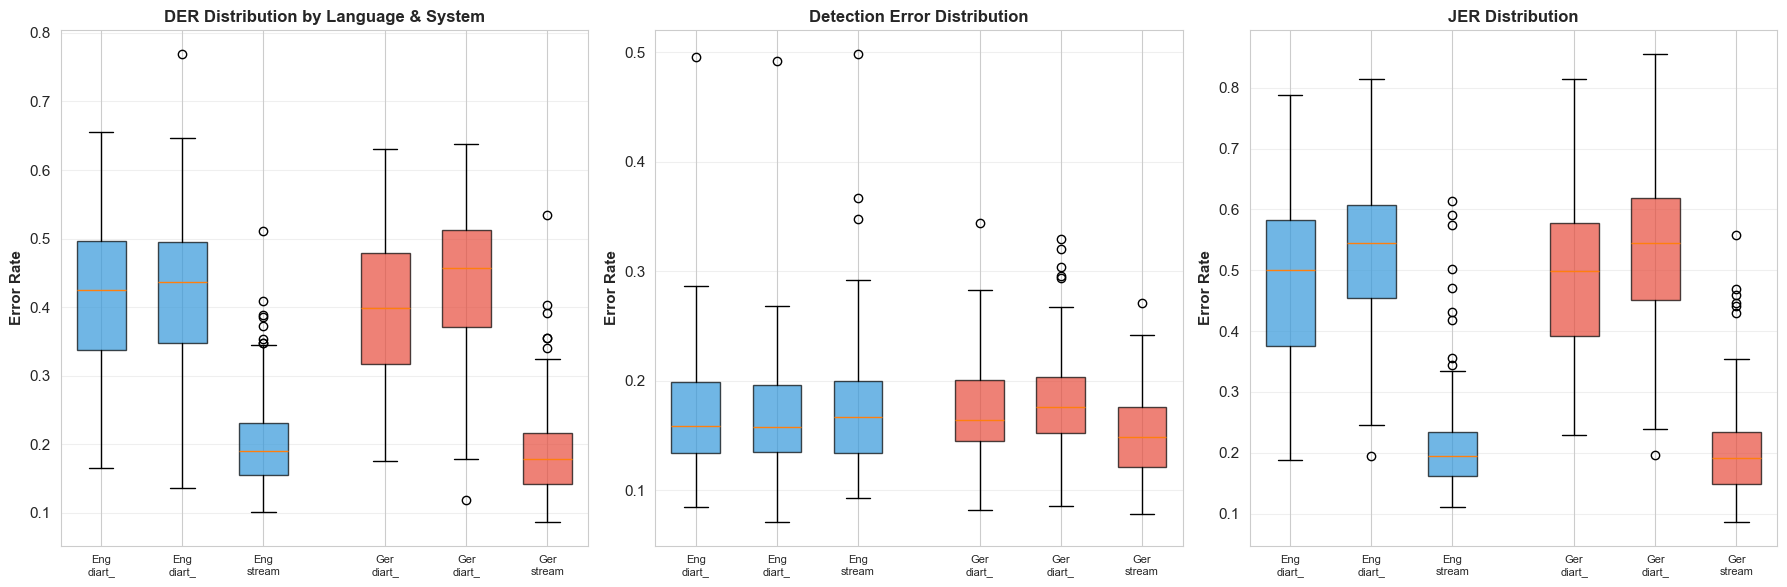

In [12]:
# Box plots to show distribution of errors across recordings
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metric_info = [
    ('DER', 'DER Distribution by Language & System', axes[0]),
    ('detection_error', 'Detection Error Distribution', axes[1]),
    ('JER', 'JER Distribution', axes[2])
]

for metric_name, title, ax in metric_info:
    # Create grouped box plot
    data_to_plot = []
    labels = []
    positions = []
    pos = 0
    
    for lang in languages:
        for sys in systems:
            subset = df_combined[(df_combined['language'] == lang) & 
                                (df_combined['system'] == sys)]
            if len(subset) > 0:
                data_to_plot.append(subset[metric_name])
                labels.append(f"{lang[:3]}\n{sys[:6]}")
                positions.append(pos)
                pos += 1
        pos += 0.5  # Add space between languages
    
    bp = ax.boxplot(data_to_plot, positions=positions, labels=labels,
                    patch_artist=True, widths=0.6)
    
    # Color by language
    colors = []
    for i in range(len(data_to_plot)):
        if i < len(systems):
            colors.append('#3498db')  # English - blue
        else:
            colors.append('#e74c3c')  # German - red
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Error Rate', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

## Key Findings Summary

In [13]:
# Generate key findings
print("="*80)
print("KEY FINDINGS: Cross-Language Performance Comparison")
print("="*80)

# Best system overall
best_overall = summary.groupby('system')[['DER', 'detection_error', 'JER']].mean().idxmin()
print(f"\nBest Overall Systems:")
print(f"  - DER: {best_overall['DER']}")
print(f"  - Detection Error: {best_overall['detection_error']}")
print(f"  - JER: {best_overall['JER']}")

# Language difficulty
avg_by_lang = df_combined.groupby('language')[['DER', 'detection_error', 'JER']].mean()
harder_lang_der = avg_by_lang['DER'].idxmax()
easier_lang_der = avg_by_lang['DER'].idxmin()

print(f"\nLanguage Difficulty (based on average DER):")
print(f"  - More challenging: {harder_lang_der} (DER: {avg_by_lang.loc[harder_lang_der, 'DER']:.4f})")
print(f"  - Less challenging: {easier_lang_der} (DER: {avg_by_lang.loc[easier_lang_der, 'DER']:.4f})")

# Performance consistency
std_by_system = df_combined.groupby('system')['DER'].std().sort_values()
print(f"\nMost Consistent System (lowest DER std dev): {std_by_system.index[0]} ({std_by_system.iloc[0]:.4f})")

print("\n" + "="*80)

KEY FINDINGS: Cross-Language Performance Comparison

Best Overall Systems:
  - DER: streaming_sortformer
  - Detection Error: streaming_sortformer
  - JER: streaming_sortformer

Language Difficulty (based on average DER):
  - More challenging: English (DER: 0.3469)
  - Less challenging: German (DER: 0.3416)

Most Consistent System (lowest DER std dev): streaming_sortformer (0.0708)

